In [ ]:
import os
from google.colab import files

# Install/upgrade Kaggle API
!pip install kaggle --upgrade

# Create the Kaggle config directory if it doesn't exist
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# Upload your Kaggle API key (kaggle.json)
uploaded = files.upload()  # This will prompt you to upload kaggle.json

# Move the uploaded kaggle.json to the correct location
for fn in uploaded.keys():
    os.replace(fn, os.path.expanduser("~/.kaggle/kaggle.json"))

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [ ]:
# Define dataset name and output path
dataset_name = "sovitrath/diabetic-retinopathy-2015-data-colored-resized"
output_path = "/content/diabetic-retinopathy-2015-resized"

# Create the output directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)

# Download and unzip the dataset
!kaggle datasets download -d {dataset_name} -p {output_path} --unzip


Dataset URL: https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-2015-data-colored-resized
License(s): CC0-1.0
 98% 1.91G/1.94G [00:15<00:00, 39.5MB/s]
100% 1.94G/1.94G [00:15<00:00, 137MB/s] 


In [ ]:
# List the extracted files
!ls {output_path}


colored_images	trainLabels.csv


In [ ]:
import pandas as pd
import os

# Load the trainLabels.csv file
labels_df = pd.read_csv('/content/diabetic-retinopathy-2015-resized/trainLabels.csv')

# Create a dictionary to map image names to labels
image_label_map = labels_df.set_index('image')['level'].to_dict()

# Define the base directory for the images
base_image_dir = '/content/diabetic-retinopathy-2015-resized/colored_images/colored_images'

# Define the subdirectories containing the images
subdirectories = ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']

# Create a list to store image paths and their corresponding labels
image_data = []

# Iterate through the subdirectories and collect image paths and labels
for subdir in subdirectories:
    subdir_path = os.path.join(base_image_dir, subdir)
    for image_name in os.listdir(subdir_path):
        # Remove the file extension to match the image name in the labels file
        image_base_name, _ = os.path.splitext(image_name)
        if image_base_name in image_label_map:
            image_path = os.path.join(subdir_path, image_name)
            label = image_label_map[image_base_name]
            image_data.append({'image_path': image_path, 'label': label})

# Create a DataFrame from the collected data
image_df = pd.DataFrame(image_data)

# Display the first few rows of the new DataFrame
display(image_df.head())

# Display the number of images found
print(f"Found {len(image_df)} images with labels.")

,image_path,label
0,/content/diabetic-retinopathy-2015-resized/col...,1
1,/content/diabetic-retinopathy-2015-resized/col...,1
2,/content/diabetic-retinopathy-2015-resized/col...,1
3,/content/diabetic-retinopathy-2015-resized/col...,1
4,/content/diabetic-retinopathy-2015-resized/col...,1


Found 35126 images with labels.


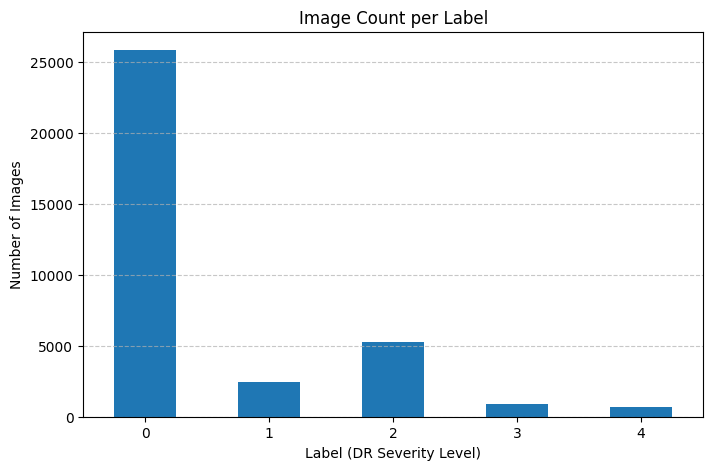

In [ ]:
import matplotlib.pyplot as plt

# Count images per label
label_counts = image_df['label'].value_counts().sort_index()

# Plot
plt.figure(figsize=(8,5))
label_counts.plot(kind='bar')

plt.title("Image Count per Label")
plt.xlabel("Label (DR Severity Level)")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [ ]:
# Separate label 0 (No_DR) and others
no_dr = image_df[image_df['label'] == 0]
other_labels = image_df[image_df['label'] != 0]

# Sample exactly 7000 from No_DR
no_dr_sampled = no_dr.sample(n=7000, random_state=42)

# Combine sampled No_DR with all other labels
image_df = pd.concat([no_dr_sampled, other_labels])

# Shuffle the dataset (optional but recommended)
image_df = image_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Final distribution of labels:")
print(image_df['label'].value_counts())

# Preview a few rows
display(image_df.head())


Final distribution of labels:
label
0    7000
2    5292
1    2443
3     873
4     708
Name: count, dtype: int64


,image_path,label
0,/content/diabetic-retinopathy-2015-resized/col...,0
1,/content/diabetic-retinopathy-2015-resized/col...,0
2,/content/diabetic-retinopathy-2015-resized/col...,0
3,/content/diabetic-retinopathy-2015-resized/col...,0
4,/content/diabetic-retinopathy-2015-resized/col...,0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import cv2

# Step 1: Check class distribution
label_counts = image_df['label'].value_counts()
print("Before augmentation:", label_counts)

# Step 2: Setup ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

augmented_images = []
augmented_labels = []

target_count = label_counts.max()  # Match minority classes to majority

for cls in [1, 3, 4]:  # Classes with fewer samples
    class_df = image_df[image_df['label'] == cls]
    n_to_generate = target_count - len(class_df)
    print(f"Augmenting class {cls} with {n_to_generate} synthetic images...")

    # Load images and prepare for augmentation
    X_cls = []
    for path in class_df['image_path']:
        img = cv2.imread(path)
        img = cv2.resize(img, (224, 224))  # Resize to match your model input size
        X_cls.append(img)
    X_cls = np.array(X_cls)

    # Normalize for datagen
    X_cls = X_cls.astype('float32') / 255.0

    # Generate augmented samples
    aug_iter = datagen.flow(X_cls, batch_size=32, shuffle=True)
    generated = 0
    while generated < n_to_generate:
        batch = next(aug_iter)
        for img in batch:
            img_uint8 = (img * 255).astype(np.uint8)
            augmented_images.append(img_uint8)
            augmented_labels.append(cls)
            generated += 1
            if generated >= n_to_generate:
                break

# Convert to DataFrame and merge with original
augmented_paths = []
for i, img in enumerate(augmented_images):
    path = f"/content/augmented_{i}.png"
    cv2.imwrite(path, img)
    augmented_paths.append(path)

aug_df = pd.DataFrame({'image_path': augmented_paths, 'label': augmented_labels})
image_df = pd.concat([image_df, aug_df], ignore_index=True)

print("After augmentation:", image_df['label'].value_counts())


Before augmentation: label
0    7000
2    5292
1    2443
3     873
4     708
Name: count, dtype: int64
Augmenting class 1 with 4557 synthetic images...
Augmenting class 3 with 6127 synthetic images...
Augmenting class 4 with 6292 synthetic images...
After augmentation: label
0    7000
1    7000
4    7000
3    7000
2    5292
Name: count, dtype: int64


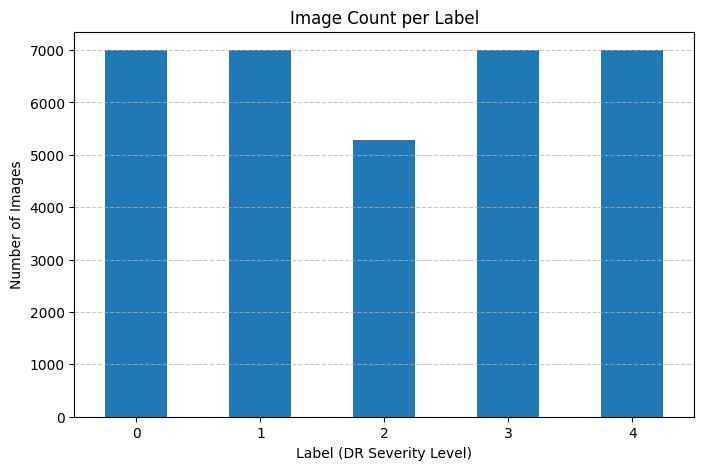

In [ ]:
import matplotlib.pyplot as plt

# Count images per label
label_counts = image_df['label'].value_counts().sort_index()

# Plot
plt.figure(figsize=(8,5))
label_counts.plot(kind='bar')

plt.title("Image Count per Label")
plt.xlabel("Label (DR Severity Level)")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


Loaded image from: /content/diabetic-retinopathy-2015-resized/colored_images/colored_images/No_DR/26747_right.png


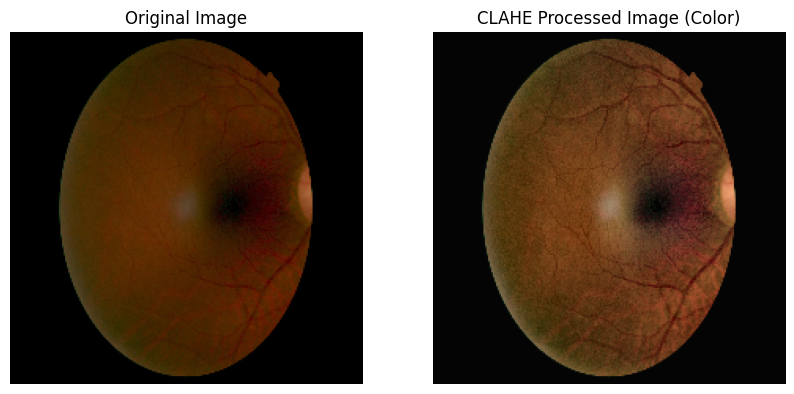

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an example image (you can replace this with a path from your image_df)
# Let's use an image path from the dataframe if available
if not image_df.empty:
    example_image_path = image_df.iloc[0]['image_path']
    try:
        img = cv2.imread(example_image_path, cv2.IMREAD_COLOR) # Load as color image
        print(f"Loaded image from: {example_image_path}")
    except Exception as e:
        print(f"Error loading image: {e}")
        # Create a dummy color image if loading fails
        img = np.uint8(np.random.rand(256, 256, 3) * 255)
        print("Created a dummy color image for demonstration.")

else:
     # Create a dummy color image if image_df is empty
     img = np.uint8(np.random.rand(256, 256, 3) * 255)
     print("Created a dummy color image for demonstration as image_df is empty.")


# Convert the image to Lab color space
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

# Split the Lab image into L, a, and b channels
l, a, b = cv2.split(lab)

# Apply CLAHE to the L channel
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_l = clahe.apply(l)

# Merge the CLAHE enhanced L channel with the original a and b channels
merged_lab = cv2.merge((clahe_l, a, b))

# Convert the Lab image back to BGR color space
clahe_img = cv2.cvtColor(merged_lab, cv2.COLOR_LAB2BGR)


# Display the original and CLAHE processed images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for displaying with matplotlib
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(clahe_img, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for displaying with matplotlib
plt.title('CLAHE Processed Image (Color)')
plt.axis('off')

plt.show()

In [ ]:
import cv2
import numpy as np

def apply_clahe_color(image_path):
    """
    Applies CLAHE to the L channel of a color image.

    Args:
        image_path (str): Path to the image file.

    Returns:
        numpy.ndarray: The CLAHE processed image in BGR format, or None if loading fails.
    """
    try:
        # Load the image in color
        img = cv2.imread(image_path, cv2.IMREAD_COLOR)

        if img is None:
            print(f"Warning: Could not load image from {image_path}")
            return None

        # Convert the image to Lab color space
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

        # Split the Lab image into L, a, and b channels
        l, a, b = cv2.split(lab)

        # Apply CLAHE to the L channel
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        clahe_l = clahe.apply(l)

        # Merge the CLAHE enhanced L channel with the original a and b channels
        merged_lab = cv2.merge((clahe_l, a, b))

        # Convert the Lab image back to BGR color space
        clahe_img = cv2.cvtColor(merged_lab, cv2.COLOR_LAB2BGR)

        return clahe_img

    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None


In [ ]:
# Initialize an empty list to store the processed images
processed_images = []

# Iterate through each row of the image_df DataFrame and apply CLAHE
from tqdm.notebook import tqdm # Import tqdm for progress bar

for index, row in tqdm(image_df.iterrows(), total=len(image_df), desc="Applying CLAHE"):
    image_path = row['image_path']
    processed_img = apply_clahe_color(image_path)

    # If the function returns a processed image, append it to the list
    if processed_img is not None:
        processed_images.append(processed_img)

print(f"Successfully processed {len(processed_images)} images.")

Applying CLAHE:   0%|          | 0/33292 [00:00<?, ?it/s]

Successfully processed 33292 images.


**Reasoning**:
Split the image_df DataFrame into training and testing sets using train_test_split.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the image_df into training and testing sets
train_df, test_df = train_test_split(image_df, test_size=0.2, random_state=42, stratify=image_df['label'])

print(f"Training set size: {len(train_df)}")
print(f"Testing set size: {len(test_df)}")

display(train_df.head())
display(test_df.head())

Training set size: 26633
Testing set size: 6659


,image_path,label
1699,/content/diabetic-retinopathy-2015-resized/col...,1
9957,/content/diabetic-retinopathy-2015-resized/col...,0
10971,/content/diabetic-retinopathy-2015-resized/col...,0
23050,/content/augmented_6734.png,3
25986,/content/augmented_9670.png,3


,image_path,label
21702,/content/augmented_5386.png,3
21760,/content/augmented_5444.png,3
19895,/content/augmented_3579.png,1
28199,/content/augmented_11883.png,4
27755,/content/augmented_11439.png,4


**Reasoning**:
Define a custom PyTorch Dataset class to load images and labels from the DataFrame and create DataLoaders for training and testing.



In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np

class DiabeticRetinopathyDataset(Dataset):
    """Custom Dataset for Diabetic Retinopathy images."""

    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe (pandas.DataFrame): DataFrame with image paths and labels.
            transform (callable, optional): Optional transform to be applied on an image.
        """
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']

        # Load image
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not load image from {img_path}. Returning dummy data.")
            # Return dummy data if image loading fails
            # Assuming image size is 256x256 and 3 channels
            dummy_img = np.zeros((224, 224, 3), dtype=np.uint8)
            img = dummy_img

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Apply transform
        if self.transform:
            img = self.transform(img)
        else:
            # Convert numpy array to tensor if no transform
            img = torch.from_numpy(img).permute(2, 0, 1).float() # Channels first, float type

        return img, label

# Define image transformations (resize and normalization)
from torchvision import transforms



# Determine the image size from a sample image if available, or set a default
sample_img_path = image_df.iloc[0]['image_path']
sample_img = cv2.imread(sample_img_path)
if sample_img is not None:
    img_height, img_width, _ = sample_img.shape
    print(f"Detected image size: {img_width}x{img_height}")
else:
    # Default size if sample image cannot be loaded
    img_height, img_width = 256, 256
    print(f"Could not detect image size, using default: {img_width}x{img_height}")


data_transform = transforms.Compose([
    # If images are not already a consistent size, add a resize transform
    # transforms.Resize((img_height, img_width)), # Uncomment if resizing is needed
    transforms.ToTensor(), # Converts numpy array to tensor and scales to [0, 1]
    # Normalize with ImageNet means and stds (common practice)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Instantiate the custom dataset for training and testing
train_dataset = DiabeticRetinopathyDataset(train_df, transform=data_transform)
test_dataset = DiabeticRetinopathyDataset(test_df, transform=data_transform)

# Define batch size
batch_size = 32 # You can adjust this based on your GPU memory

# Create PyTorch DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Number of samples in training dataset: {len(train_dataset)}")
print(f"Number of samples in testing dataset: {len(test_dataset)}")
print(f"Number of batches in training dataloader: {len(train_dataloader)}")
print(f"Number of batches in testing dataloader: {len(test_dataloader)}")

Detected image size: 224x224
Number of samples in training dataset: 26633
Number of samples in testing dataset: 6659
Number of batches in training dataloader: 833
Number of batches in testing dataloader: 209


## Instantiate the model

### Subtask:
Create an instance of the `ResNet18_CBAM_Classifier` model.


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# ---- CBAM Block (same as before, but kept lightweight) ----
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_out = torch.cat([avg_out, max_out], dim=1)
        x_out = self.conv1(x_out)
        return self.sigmoid(x_out)

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# ---- EfficientNet with CBAM ----
class EfficientNet_CBAM(nn.Module):
    def __init__(self, num_classes=5):
        super(EfficientNet_CBAM, self).__init__()
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # Modify last layer
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Identity()  # remove classifier

        # CBAM after final feature map
        self.cbam = CBAM(in_planes=in_features)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.backbone.features(x)  # Get feature maps
        x = self.cbam(x)               # Apply CBAM attention
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Example usage
model = EfficientNet_CBAM(num_classes=5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(model)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 129MB/s] 


EfficientNet_CBAM(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (

## Define loss function and optimizer

### Subtask:
Choose an appropriate loss function and optimizer for training the model.


**Reasoning**:
Define the loss function and optimizer for training the model.



In [ ]:
import torch.nn as nn
import torch.optim as optim

# Define the loss function (Cross-Entropy Loss for multi-class classification)
criterion = nn.CrossEntropyLoss()

# Define the optimizer (Adam optimizer)
# Pass the model's parameters and specify the learning rate
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Print the chosen loss function and optimizer
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
# Set the model to training mode
model.train()

running_loss = 0.0

# Iterate over the training data
from tqdm.notebook import tqdm # Import tqdm for progress bar

for inputs, labels in tqdm(train_dataloader, desc="Training"):
    # Move data to the appropriate device
    inputs, labels = inputs.to(device), labels.to(device)

    # Zero the parameter gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(inputs)
    loss = criterion(outputs, labels)

    # Backward pass and optimize
    loss.backward()
    optimizer.step()

    # Accumulate the loss
    running_loss += loss.item() * inputs.size(0)

# Calculate the average training loss for the epoch
epoch_loss = running_loss / len(train_dataset)

print(f"Training Loss: {epoch_loss:.4f}")

Training:   0%|          | 0/833 [00:00<?, ?it/s]

Training Loss: 0.8963


In [ ]:
import torch
from tqdm.notebook import tqdm

# Ensure model, loss, optimizer are already defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device)

num_epochs = 2

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # Training loop with progress bar
    for inputs, labels in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        # Move data to device (CUDA if available)
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item() * inputs.size(0)

    # Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{num_epochs} - Training Loss: {epoch_loss:.4f}")


Using device: cuda


Epoch 1/2:   0%|          | 0/833 [00:00<?, ?it/s]

Epoch 1/2 - Training Loss: 0.5919


Epoch 2/2:   0%|          | 0/833 [00:00<?, ?it/s]

Epoch 2/2 - Training Loss: 0.5133


In [ ]:
import torch
from tqdm.notebook import tqdm

# Ensure model, loss, optimizer are already defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device)

num_epochs = 1

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # Training loop with progress bar
    for inputs, labels in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        # Move data to device (CUDA if available)
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item() * inputs.size(0)

    # Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{num_epochs} - Training Loss: {epoch_loss:.4f}")


Using device: cuda


Epoch 1/1:   0%|          | 0/833 [00:00<?, ?it/s]

Epoch 1/1 - Training Loss: 0.4584


In [ ]:
import torch

# Set the model to evaluation mode
model.eval()

running_loss = 0.0
correct_predictions = 0
total_samples = 0

# Disable gradient calculation for evaluation
with torch.no_grad():
    # Iterate over the testing data
    from tqdm.notebook import tqdm # Import tqdm for progress bar

    for i, (inputs, labels) in enumerate(tqdm(test_dataloader, desc="Evaluating")):
        # Move data to the appropriate device
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Accumulate the loss
        running_loss += loss.item() * inputs.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

        # Display actual and predicted for the first few batches
        if i < 5:  # Display for the first 5 batches
            print(f"\nBatch {i+1}")
            print("Actual labels:", labels.cpu().numpy())
            print("Predicted labels:", predicted.cpu().numpy())


# Calculate the average testing loss
epoch_loss = running_loss / len(test_dataset)

# Calculate the accuracy
accuracy = correct_predictions / total_samples

print(f"\nTesting Loss: {epoch_loss:.4f}")
print(f"Testing Accuracy: {accuracy:.4f}")

Evaluating:   0%|          | 0/209 [00:00<?, ?it/s]


Batch 1
Actual labels: [3 3 1 4 4 2 1 1 2 2 1 4 4 0 2 1 1 3 0 1 1 1 3 3 0 3 2 4 3 0 1 2]
Predicted labels: [3 3 1 4 4 2 1 0 0 2 0 4 4 0 2 1 1 3 0 1 0 1 3 3 0 3 0 4 3 0 3 0]

Batch 2
Actual labels: [1 2 2 0 4 0 4 1 0 4 1 4 1 3 0 3 1 3 4 1 4 4 0 0 4 0 3 3 1 0 4 4]
Predicted labels: [0 4 0 0 4 0 2 1 2 4 1 4 1 3 0 3 1 3 3 1 4 4 0 0 4 0 3 3 0 0 4 4]

Batch 3
Actual labels: [3 0 4 3 4 0 0 1 0 3 4 4 0 1 4 1 2 0 3 1 0 0 0 4 1 0 1 0 2 1 0 4]
Predicted labels: [3 0 2 3 4 0 0 1 0 3 4 4 0 1 3 1 0 0 1 1 0 0 0 4 1 0 1 0 0 0 2 4]

Batch 4
Actual labels: [2 3 2 4 4 1 2 2 2 1 1 4 1 4 2 1 1 2 2 1 4 1 4 3 0 0 4 1 4 2 3 3]
Predicted labels: [2 3 4 4 4 1 2 0 2 1 1 4 2 4 2 0 1 0 2 1 4 1 4 3 0 0 4 1 4 2 3 3]

Batch 5
Actual labels: [4 0 3 0 0 3 3 3 1 2 0 0 3 0 1 1 0 4 0 1 4 1 1 3 2 3 0 4 4 3 0 4]
Predicted labels: [4 0 3 0 0 3 3 3 1 0 0 0 2 2 1 0 0 4 2 2 4 1 1 3 3 1 0 4 4 3 0 4]

Testing Loss: 0.5791
Testing Accuracy: 0.7578


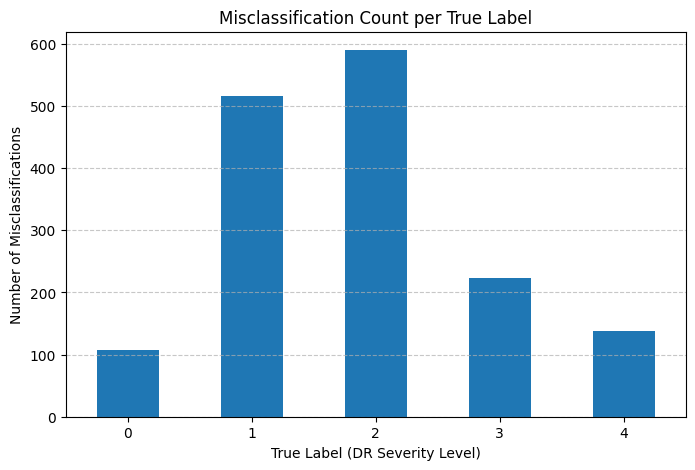

Misclassification counts per true label:
0    107
1    516
2    590
3    224
4    138
dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

# Initialize a dictionary to store misclassification counts per true class
misclassification_counts = defaultdict(int)

# Iterate through the test results and count misclassifications
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # Compare predicted and actual labels
        misclassified_indices = (predicted != labels).nonzero(as_tuple=True)[0]

        # Count misclassifications for each true class
        for idx in misclassified_indices:
            true_label = labels[idx].item()
            misclassification_counts[true_label] += 1

# Convert the misclassification counts to a pandas Series for plotting
misclassification_series = pd.Series(misclassification_counts).sort_index()

# Plot the misclassification counts
plt.figure(figsize=(8, 5))
misclassification_series.plot(kind='bar')

plt.title("Misclassification Count per True Label")
plt.xlabel("True Label (DR Severity Level)")
plt.ylabel("Number of Misclassifications")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print("Misclassification counts per true label:")
print(misclassification_series)

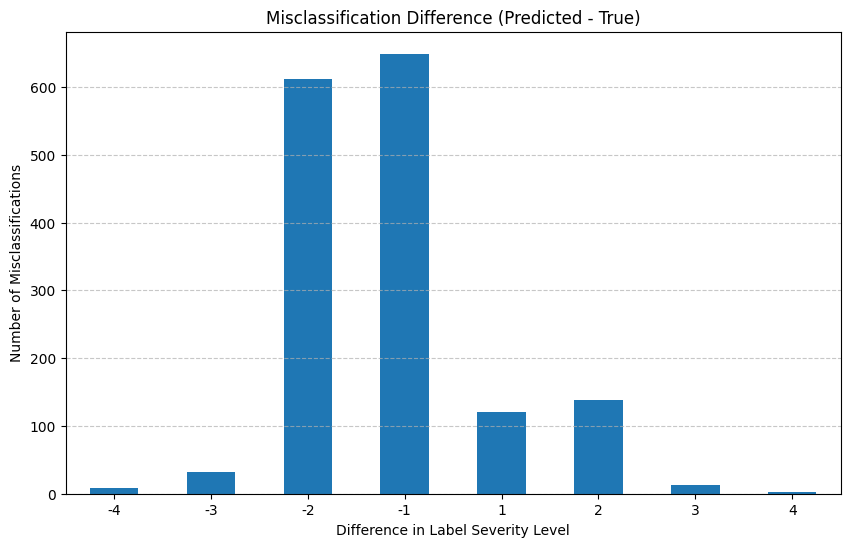

Misclassification difference counts:
-4      8
-3     32
-2    612
-1    649
 1    120
 2    138
 3     13
 4      3
dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

# Initialize a dictionary to store the difference between predicted and actual labels for misclassified images
misclassification_diffs = defaultdict(int)

# Iterate through the test results and calculate differences for misclassifications
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # Compare predicted and actual labels
        misclassified_indices = (predicted != labels).nonzero(as_tuple=True)[0]

        # Calculate and store the difference for misclassified samples
        for idx in misclassified_indices:
            true_label = labels[idx].item()
            predicted_label = predicted[idx].item()
            difference = predicted_label - true_label
            misclassification_diffs[difference] += 1

# Convert the misclassification differences to a pandas Series for plotting
misclassification_diffs_series = pd.Series(misclassification_diffs).sort_index()

# Plot the misclassification differences
plt.figure(figsize=(10, 6))
misclassification_diffs_series.plot(kind='bar')

plt.title("Misclassification Difference (Predicted - True)")
plt.xlabel("Difference in Label Severity Level")
plt.ylabel("Number of Misclassifications")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print("Misclassification difference counts:")
print(misclassification_diffs_series)

In [ ]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

# Set the model to evaluation mode
model.eval()

all_labels = []
all_predicted = []

# Disable gradient calculation for evaluation
with torch.no_grad():
    # Iterate over the testing data
    from tqdm.notebook import tqdm # Import tqdm for progress bar

    for inputs, labels in tqdm(test_dataloader, desc="Calculating QWK"):
        # Move data to the appropriate device
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predicted.extend(predicted.cpu().numpy())

# Calculate the Quadratic Weighted Kappa (QWK) score
qwk_score = cohen_kappa_score(all_labels, all_predicted, weights='quadratic')

print(f"\nQuadratic Weighted Kappa (QWK) Score: {qwk_score:.4f}")

Calculating QWK:   0%|          | 0/209 [00:00<?, ?it/s]


Quadratic Weighted Kappa (QWK) Score: 0.8581


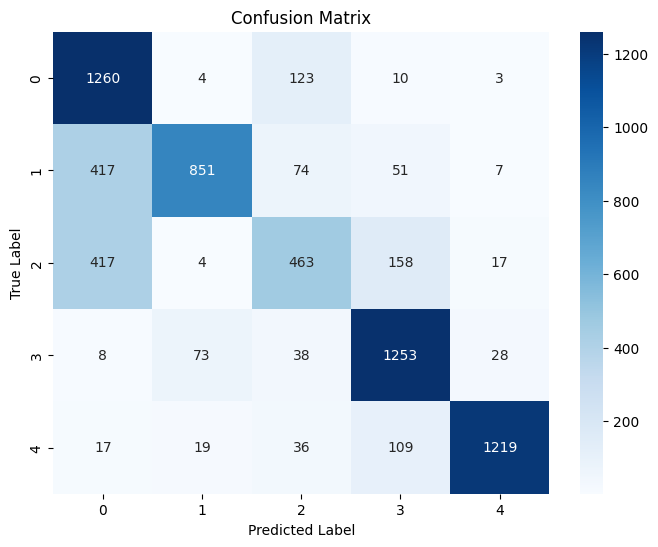

Confusion Matrix:
[[1260    4  123   10    3]
 [ 417  851   74   51    7]
 [ 417    4  463  158   17]
 [   8   73   38 1253   28]
 [  17   19   36  109 1219]]


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ensure model is in evaluation mode and data is on the correct device
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_labels = []
all_predicted = []

# Disable gradient calculation for evaluation and collect predictions
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predicted.extend(predicted.cpu().numpy())

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_predicted)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2, 3, 4],
            yticklabels=[0, 1, 2, 3, 4])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Confusion Matrix:")
print(cm)


Processing image: /content/augmented_5386.png
Actual Label: 3 (Severe)
Predicted Label: 3 (Severe)


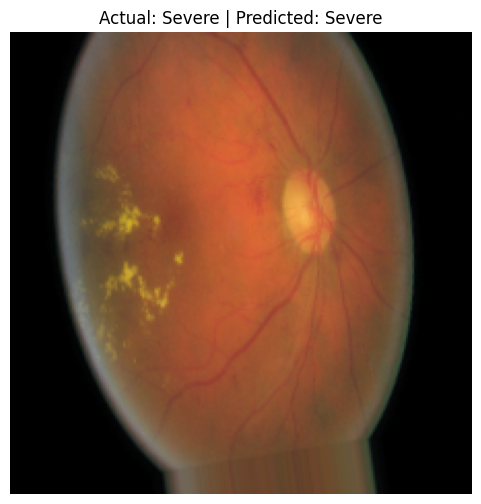


Processing image: /content/augmented_5444.png
Actual Label: 3 (Severe)
Predicted Label: 3 (Severe)


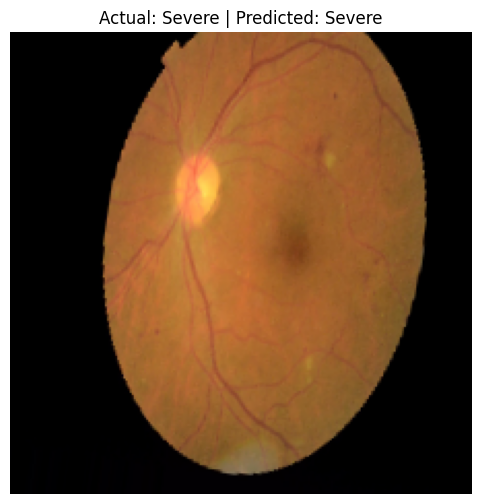


Processing image: /content/augmented_3579.png
Actual Label: 1 (Mild)
Predicted Label: 1 (Mild)


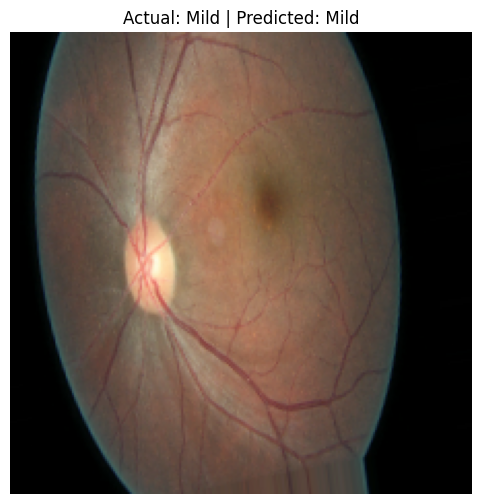


Processing image: /content/augmented_11883.png
Actual Label: 4 (Proliferate_DR)
Predicted Label: 4 (Proliferate_DR)


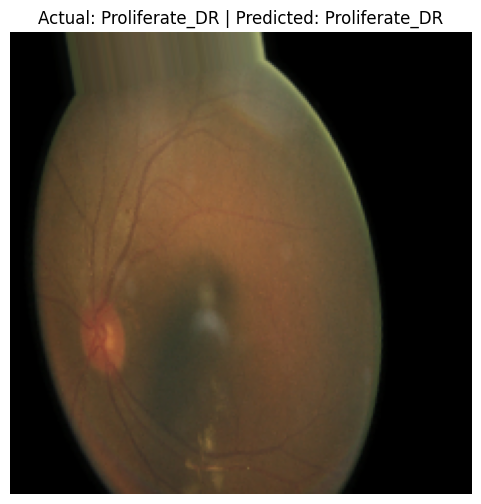


Processing image: /content/augmented_11439.png
Actual Label: 4 (Proliferate_DR)
Predicted Label: 4 (Proliferate_DR)


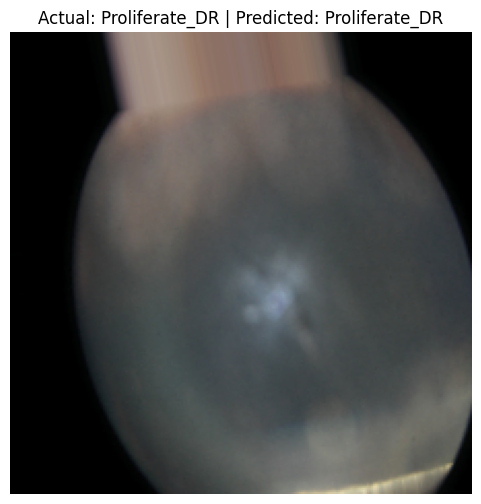

In [ ]:
import torch
import cv2
import numpy as np
from torchvision import transforms
import matplotlib.pyplot as plt

# Define a mapping from label (0-4) to severity level name
label_to_severity = {
    0: "No_DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferate_DR"
}

# Set the model to evaluation mode
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get the first 5 images from the test DataFrame
sample_images_df = test_df.head(5).reset_index(drop=True)

for index, row in sample_images_df.iterrows():
    sample_image_path = row['image_path']
    actual_label = row['label']
    actual_severity = label_to_severity.get(actual_label, "Unknown")

    print(f"\nProcessing image: {sample_image_path}")

    img = cv2.imread(sample_image_path)
    if img is None:
        print(f"Error: Could not load image from {sample_image_path}")
    else:
        # Convert BGR to RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Apply the same transformations used for the dataset
        if 'data_transform' in globals():
            input_tensor = data_transform(img_rgb)
            input_batch = input_tensor.unsqueeze(0) # Add a batch dimension
        else:
            print("Error: 'data_transform' is not defined. Please run the data loader cell first.")
            input_batch = None

        if input_batch is not None:
            # Move the input to the same device as the model
            input_batch = input_batch.to(device)

            # Make a prediction
            with torch.no_grad():
                output = model(input_batch)

            # Get the predicted class
            _, predicted_class = torch.max(output.data, 1)
            predicted_label = predicted_class.item()

            # Get the severity level name
            predicted_severity = label_to_severity.get(predicted_label, "Unknown")

            print(f"Actual Label: {actual_label} ({actual_severity})")
            print(f"Predicted Label: {predicted_label} ({predicted_severity})")

            # Optional: Display the image
            plt.figure(figsize=(6, 6))
            plt.imshow(img_rgb)
            plt.title(f"Actual: {actual_severity} | Predicted: {predicted_severity}")
            plt.axis('off')
            plt.show()

In [ ]:
import torch

# Define the path where you want to save the model
model_save_path = 'efficientnet_cbam_dr_classification.pth'

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)

print(f"Model saved successfully to {model_save_path}")

Model saved successfully to efficientnet_cbam_dr_classification.pth


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Reasoning**:
Train the model for one epoch following the steps outlined in the instructions.

